# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import LabelEncoder

# Loading DataSet

In [2]:
df = pd.read_csv("google_playstore_data.csv")

# Initial Exploration

In [3]:
# Displays the first 5 rows of the dataset.
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver
0,AI Browser,Food_And_Drink,3.95,3,14.60,500,Free,0.0,Everyone,Food And Drink,12-06-2026,4.10.23
1,AI Browser 3D 2025,Social,3.90,1,137.90,50,Free,0.0,Everyone,Social;Creativity,19-07-2024,4.11.15
2,AI Browser Hub,Productivity,4.00,2,100.20,100,Free,0.0,Everyone,Productivity,07-12-2025,12.8.72
3,AI Browser Plus,Events,3.80,2,43.20,50,Free,0.0,Everyone,Events;Creativity,05-10-2025,1.16.26
4,AI Chat,Game,3.50,1169,90.05,50000,Free,0.0,Everyone 10+,Game;Puzzle,22-06-2026,Varies with device


In [4]:
# Displays the last 5 rows of the dataset.
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver
2372,Wallet_8694,Finance,4.0,10,35.10,500,Free,0.0,Everyone,Finance,23-04-2026,10.19.76
2373,Wallet_953,Social,4.6,5,38.50,50,Free,0.0,Everyone,Family,14-12-2024,15.18.12
2374,WhatsApp Messenger,Social,4.6,12460594,90.05,500000000,Free,0.0,Teen,Family,15-01-2026,Varies with device
2375,WhatsApp Messenger 2024,Music,3.3,5,8.40,50,Free,0.0,Everyone,Tools,03-02-2025,6.18.49
2376,Youtube,Social,4.8,1462981,76.20,50000000,Free,0.0,Everyone,Artificial Intelligence,24-05-2023,3.11.39


In [5]:
# Returns the number of rows and columns in the dataset.
df.shape

(2377, 12)

In [6]:
# Lists all column names in the dataset.
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver'],
      dtype='str')

In [7]:
# Shows a summary of the dataset, including data types and missing values.
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2377 entries, 0 to 2376
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             2377 non-null   str    
 1   Category        2377 non-null   str    
 2   Rating          2377 non-null   float64
 3   Reviews         2377 non-null   int64  
 4   Size            2377 non-null   float64
 5   Installs        2377 non-null   int64  
 6   Type            2377 non-null   str    
 7   Price           2377 non-null   float64
 8   Content Rating  2377 non-null   str    
 9   Genres          2377 non-null   str    
 10  Last Updated    2377 non-null   str    
 11  Current Ver     2377 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 223.0 KB


In [8]:
# Generates descriptive statistics for columns.
df.describe(include = 'all') 

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver
count,2377,2377,2377.000000,2.377000e+03,2377.000000,2.377000e+03,2377,2377.000000,2377,2377,2377,2377
unique,2377,31,NaN,NaN,NaN,NaN,2,NaN,6,79,920,1943
top,AI Browser,Social,NaN,NaN,NaN,NaN,Free,NaN,Everyone,Family,23-04-2026,Varies with device
freq,1,744,NaN,NaN,NaN,NaN,2280,NaN,1647,312,12,374
mean,NaN,NaN,4.067228,3.620377e+04,181.297602,1.477158e+06,NaN,0.338675,NaN,NaN,NaN,NaN
std,NaN,NaN,0.483467,4.472052e+05,340.945930,1.892065e+07,NaN,8.375179,NaN,NaN,NaN,NaN
min,NaN,NaN,2.000000,0.000000e+00,5.000000,1.000000e+01,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,3.900000,3.000000e+00,55.300000,1.000000e+02,NaN,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.000000,2.000000e+01,90.050000,1.000000e+03,NaN,0.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.300000,4.110000e+02,124.800000,1.000000e+04,NaN,0.000000,NaN,NaN,NaN,NaN


# Data Cleaning

In [9]:
df.duplicated().sum()  
# Counts the total number of duplicate rows present in the dataset.
df.drop_duplicates(inplace=True)  
# Removes all duplicate rows from the dataset and updates the original DataFrame directly.

In [10]:
df.isnull().sum() 
# Counts the number of missing (NULL/NaN) values in each column of the dataset.

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
dtype: int64

In [11]:
# Fills missing values in the Rating column with the median rating of each app category.
df['Rating'] = df.groupby('Category')['Rating'].transform(
    lambda x: x.fillna(x.median())
)

In [12]:
df.isnull().sum() 
# Counts the number of missing (NULL/NaN) values in each column of the dataset.

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
dtype: int64

In [13]:
# Converts the Reviews column from string (object) to integer (int) for numerical analysis.
df['Reviews'] = df['Reviews'].astype(int)

In [14]:
# CHecking the data type of Review.
df['Reviews'].dtype

dtype('int64')

In [15]:
# CHecking the data type of Install.
df['Installs'].dtype

dtype('int64')

In [16]:
# Convert the column to numeric
df['Size'] = pd.to_numeric(df['Size'])

In [17]:
# To check
df['Size'].head()

0     14.60
1    137.90
2    100.20
3     43.20
4     90.05
Name: Size, dtype: float64

In [18]:
df['Size'].dtype

dtype('float64')

In [19]:
# We fill the empty size blocks with the median of the size, which are created while we performning the data cleaning in size.
df.fillna({'Size': df['Size'].median()}, inplace=True)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver
0,AI Browser,Food_And_Drink,3.95,3,14.60,500,Free,0.0,Everyone,Food And Drink,12-06-2026,4.10.23
1,AI Browser 3D 2025,Social,3.90,1,137.90,50,Free,0.0,Everyone,Social;Creativity,19-07-2024,4.11.15
2,AI Browser Hub,Productivity,4.00,2,100.20,100,Free,0.0,Everyone,Productivity,07-12-2025,12.8.72
3,AI Browser Plus,Events,3.80,2,43.20,50,Free,0.0,Everyone,Events;Creativity,05-10-2025,1.16.26
4,AI Chat,Game,3.50,1169,90.05,50000,Free,0.0,Everyone 10+,Game;Puzzle,22-06-2026,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...
2372,Wallet_8694,Finance,4.00,10,35.10,500,Free,0.0,Everyone,Finance,23-04-2026,10.19.76
2373,Wallet_953,Social,4.60,5,38.50,50,Free,0.0,Everyone,Family,14-12-2024,15.18.12
2374,WhatsApp Messenger,Social,4.60,12460594,90.05,500000000,Free,0.0,Teen,Family,15-01-2026,Varies with device
2375,WhatsApp Messenger 2024,Music,3.30,5,8.40,50,Free,0.0,Everyone,Tools,03-02-2025,6.18.49


In [20]:
# CHecking the correction.
df['Size'].isnull().sum()

np.int64(0)

In [21]:
# Verify the data type
df['Last Updated'].dtype

<StringDtype(storage='python', na_value=nan)>

In [22]:
# Standardizes category names by removing extra spaces, converting them to a consistent format, 
# and merging duplicate category names into a single value.
df['Category'] = df['Category'].str.strip().str.title()

In [23]:
df['Category'].unique()

<StringArray>
[     'Food_And_Drink',              'Social',        'Productivity',
              'Events',                'Game',            'Business',
    'Travel_And_Local',               'Music',              'Beauty',
            'Shopping',         'Photography',              'Dating',
       'Communication',   'Auto_And_Vehicles',             'Finance',
     'Personalization',              'Comics',       'Entertainment',
  'News_And_Magazines',     'Virtual_Reality',  'Health_And_Fitness',
 'Books_And_Reference',           'Parenting',       'Video_Players',
 'Maps_And_Navigation',      'House_And_Home',  'Libraries_And_Demo',
     'Web3_And_Crypto',           'Lifestyle',              'Sports',
             'Weather']
Length: 31, dtype: str

# Feature Engineering

### 1. Revenue Estimate

In [24]:
# Creates an estimated revenue feature by multiplying the app price by the total number of installs.
df['Revenue Estimate'] = df['Price'] * df['Installs']

In [30]:
# Verify
df[['Price', 'Installs', 'Revenue Estimate']].sample(10)

,Price,Installs,Revenue Estimate
2110,0.0,1000,0.0
2040,0.0,100000,0.0
1603,0.0,5000,0.0
518,0.0,50,0.0
2068,0.0,50000,0.0
2290,0.0,10,0.0
2265,0.0,500000,0.0
77,0.0,100,0.0
148,0.0,10000,0.0
922,0.0,10,0.0


### 2. Review Engagement

In [31]:
# Calculates the proportion of reviews to installs, indicating user engagement with the app.

df['Review Engagement'] = np.where(
    df['Installs'] > 0,
    df['Reviews'] / df['Installs'],
    0
)

In [32]:
# Verify
df[['Reviews', 'Installs', 'Review Engagement']].head()

,Reviews,Installs,Review Engagement
0,3,500,0.00600
1,1,50,0.02000
2,2,100,0.02000
3,2,50,0.04000
4,1169,50000,0.02338


### 3. Install Group

In [33]:
# Groups apps into installation categories for easier comparison and visualization.

bins = [0, 10000, 100000, 1000000, float('inf')]
labels = ['Low', 'Medium', 'High', 'Very High']

df['Install Group'] = pd.cut(
    df['Installs'],
    bins=bins,
     labels=labels
)

In [34]:
# Verify
df[['Installs', 'Install Group']].sample(5)

,Installs,Install Group
728,50,Low
683,50,Low
867,5000,Low
164,10000000,Very High
814,50,Low


### 4. Rating Class

In [35]:
# Categorizes app ratings into performance groups for simplified analysis and reporting. 
bins = [0, 2.5, 3.5, 4.5, 5]
labels = ['Poor', 'Average', 'Good', 'Excellent']

df['Rating Class'] = pd.cut(
    df['Rating'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [36]:
# Verify
df[['Rating', 'Rating Class']].head()

,Rating,Rating Class
0,3.95,Good
1,3.90,Good
2,4.00,Good
3,3.80,Good
4,3.50,Average


# Exploratory Data Analysis (EDA)

### ~ Business Questions

#### Visualization 1 – Distribution of App Categories
#### Q1 - Which app categories dominate the Google Play Store?

C:\Users\prade\AppData\Local\Temp\ipykernel_10376\4147121345.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


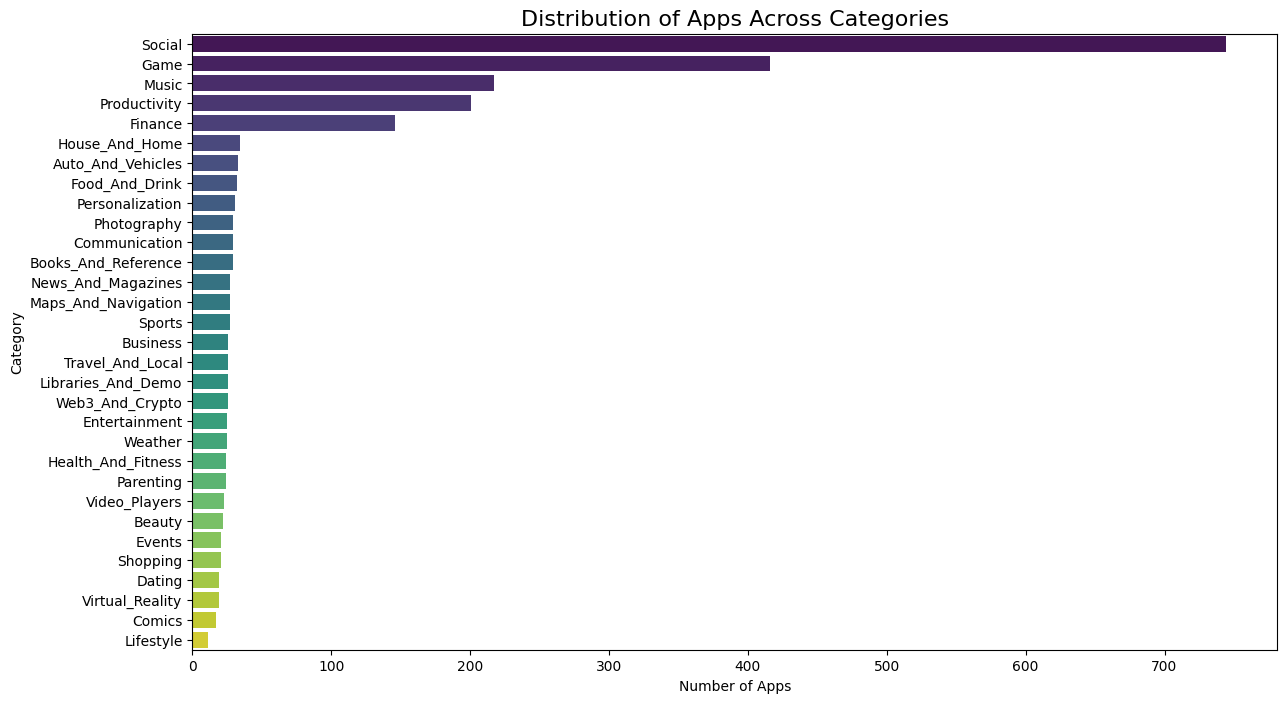

In [37]:
# A count plot displays the number of apps in each category, helping identify the most and least represented app categories on the Google Play Store.

plt.figure(figsize=(14, 8))

sns.countplot(
    data=df,
    y='Category',
    order=df['Category'].value_counts().index,
    palette='viridis'
)

plt.title('Distribution of Apps Across Categories', fontsize=16)
plt.xlabel('Number of Apps')
plt.ylabel('Category')

plt.show()

### Business Insight
#### Identify the categories with the highest number of apps and discuss market competition and potential opportunities.

### Visualization 2 – Average Rating by Category
#### Q2 - Which app categories satisfy users the most?

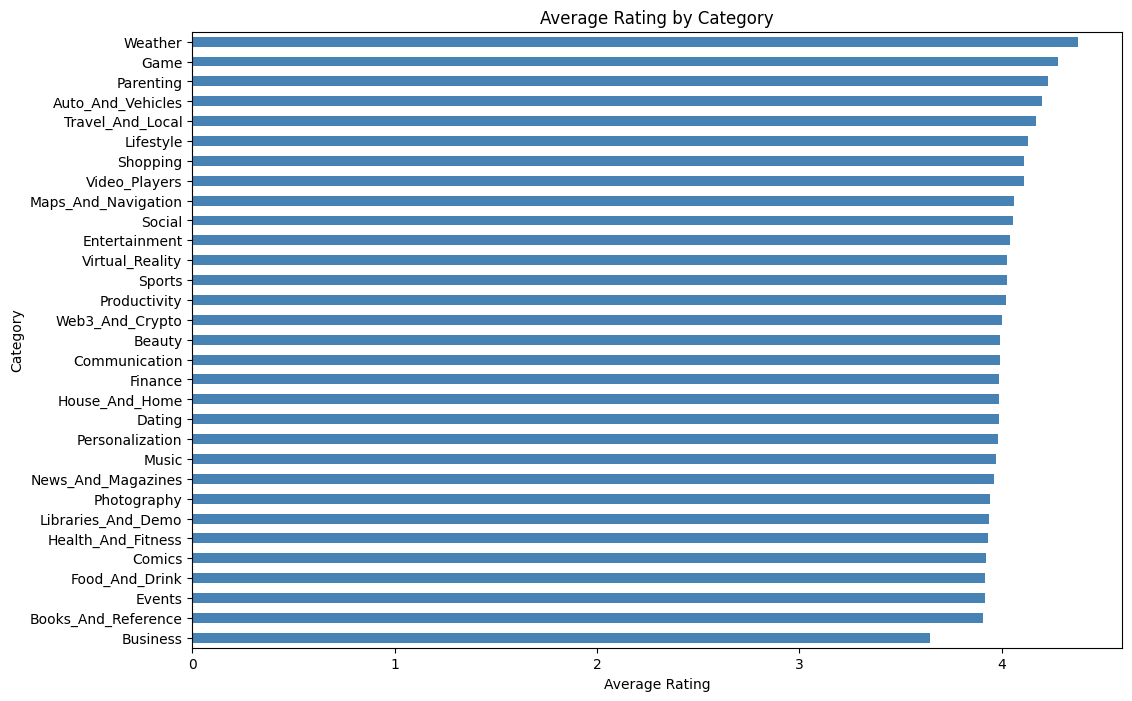

In [38]:
# Shows the average rating for each category, highlighting which categories receive the highest user satisfaction.

avg_rating = (
    df.groupby('Category')['Rating']
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,8))

avg_rating.plot(
    kind='barh',
    color='steelblue'
)

plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')

plt.show()

### Business Insight
#### Discuss the highest and lowest-rated categories and what this may indicate about user expectations.

### Visualization 3 – Top Categories by Total Installs
#### Q3 - Which app categories attract the largest number of users?

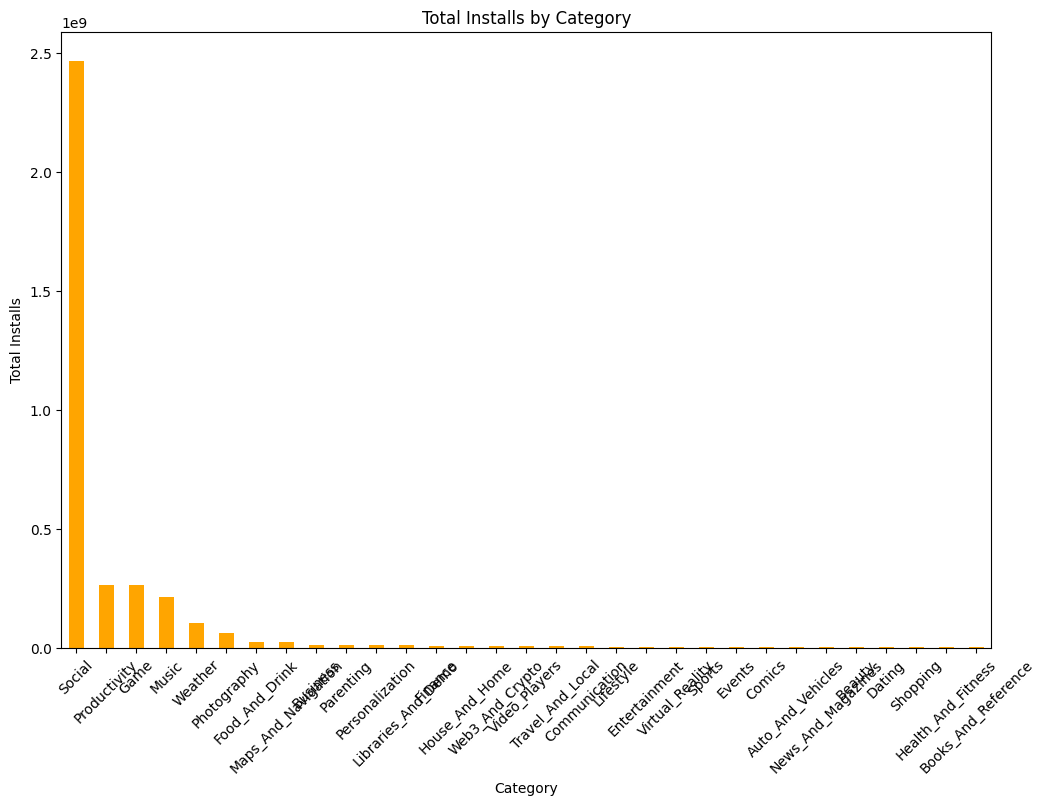

In [39]:
# Displays the total number of installs for each category to identify the most popular app categories.
top_installs = (
    df.groupby('Category')['Installs']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

top_installs.plot(
    kind='bar',
    color='orange'
)

plt.title('Total Installs by Category')
plt.xlabel('Category')
plt.ylabel('Total Installs')

plt.xticks(rotation=45)

plt.show()

### Business Insight

#### Highlight the categories that attract the highest user traffic and discuss their market demand.

### Visualization 4 – Paid vs Free Apps
#### Q4 - Which business model dominates the Google Play Store?

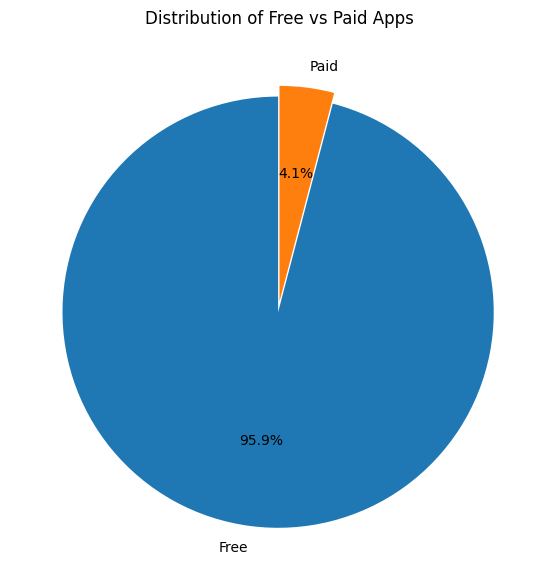

In [40]:
# Illustrates the proportion of free and paid apps available on the Google Play Store.

type_counts = df['Type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05,0]
)

plt.title('Distribution of Free vs Paid Apps')

plt.show()

### Business Insight

#### Explain whether developers primarily rely on free or paid business models and discuss possible monetization strategies.

### Visualization 5 – Revenue Estimate by Category
#### Q5 - Which app categories generate the highest estimated revenue?

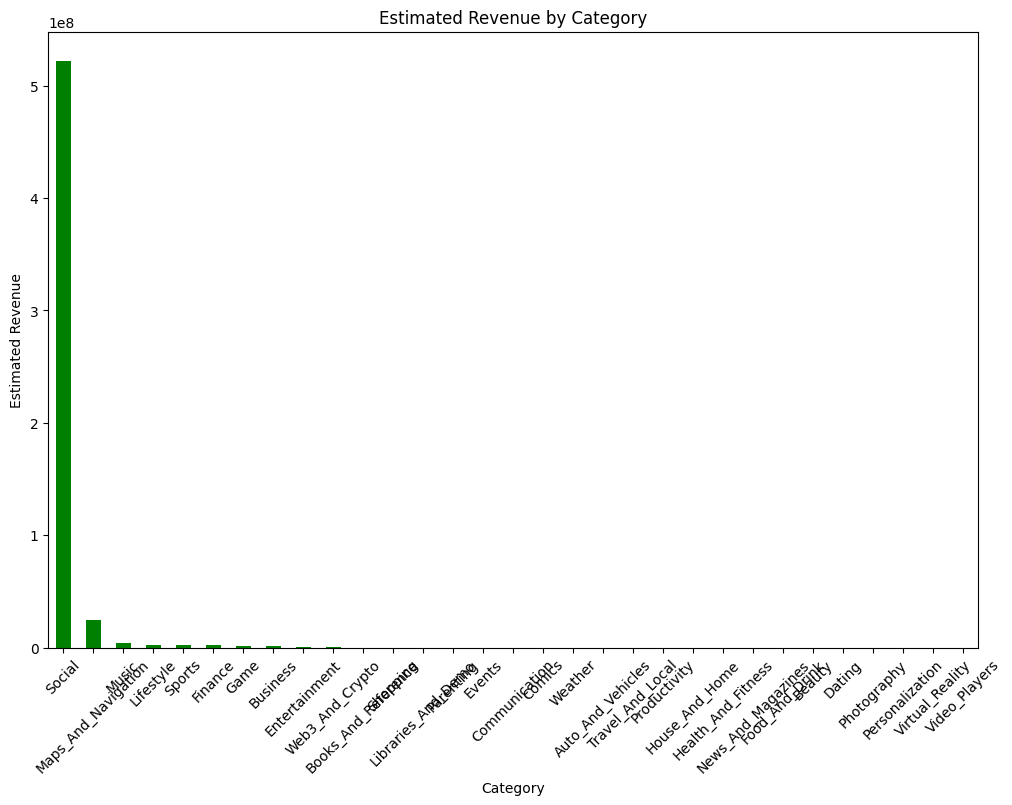

In [41]:
# Compares the estimated revenue generated by different app categories based on price and installs.

revenue = (
    df.groupby('Category')['Revenue Estimate']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

revenue.plot(
    kind='bar',
    color='green'
)

plt.title('Estimated Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Estimated Revenue')

plt.xticks(rotation=45)

plt.show()

### Business Insight

#### Identify the highest revenue-generating categories and discuss potential business opportunities.

### Visualization 6 – Correlation Heatmap
#### Q6 - Which numerical features are strongly related?

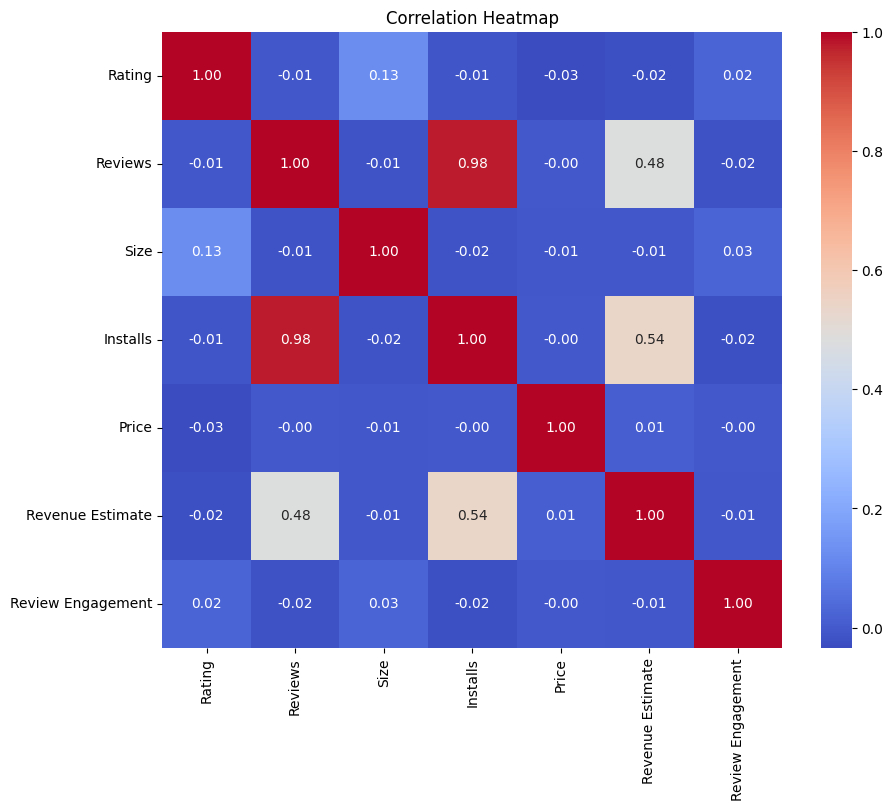

In [42]:
# Displays the correlation between numerical features, helping identify positive and negative relationships.

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Business Insight
#### Discuss the strongest positive and negative correlations and explain how these relationships can support business decisions.

###  Key Business Insights

# Business Insights

### 1. Free Apps Dominate the Google Play Store

#### :- The analysis shows that free applications make up the majority of apps on the Google Play Store. This indicates that developers primarily             rely on advertisements and in-app purchases rather than charging users upfront.

### 2. Social Category Attracts the Highest Number of Users

#### :- The Social category records the highest number of total installs, making it one of the most competitive and popular segments on the Google Play Store.

### 3. High-Rated Categories Demonstrate Strong User Satisfaction

#### :- Categories with the highest average ratings consistently deliver better user experiences, indicating higher customer satisfaction and app quality.

### 4. Paid Apps Represent a Small Portion of the Market

#### :- Paid applications account for a relatively small share of the marketplace, suggesting that most developers prefer free or freemium business models to reach a larger audience.

### 5. High User Engagement is Associated with More Reviews

#### :- Apps receiving a large number of installs also tend to accumulate more user reviews, indicating a strong relationship between popularity and user engagement.

### 6. Revenue is Concentrated in Specific Categories

#### :- A few app categories contribute a significant portion of the estimated revenue, highlighting categories with strong monetization potential.

### 7. Numerical Features Show Meaningful Relationships

#### :- The correlation analysis reveals strong relationships among numerical features such as installs, reviews, and estimated revenue, providing insights into user behavior and app performance.

### 8. Market Opportunities Exist in Less Competitive Categories

#### :- While categories like Games contain a large number of applications, several smaller categories have fewer competitors, presenting potential opportunities for new developers.

# Creating New CSV with Cleaned DataSet

In [43]:
# Save the cleaned dataset to a new CSV file
df.to_csv('google_playstore_cleaned_data.csv', index=False)

In [44]:
cleaned_df = pd.read_csv('google_playstore_cleaned_data.csv')

cleaned_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Revenue Estimate,Review Engagement,Install Group,Rating Class
0,AI Browser,Food_And_Drink,3.95,3,14.60,500,Free,0.0,Everyone,Food And Drink,12-06-2026,4.10.23,0.0,0.00600,Low,Good
1,AI Browser 3D 2025,Social,3.90,1,137.90,50,Free,0.0,Everyone,Social;Creativity,19-07-2024,4.11.15,0.0,0.02000,Low,Good
2,AI Browser Hub,Productivity,4.00,2,100.20,100,Free,0.0,Everyone,Productivity,07-12-2025,12.8.72,0.0,0.02000,Low,Good
3,AI Browser Plus,Events,3.80,2,43.20,50,Free,0.0,Everyone,Events;Creativity,05-10-2025,1.16.26,0.0,0.04000,Low,Good
4,AI Chat,Game,3.50,1169,90.05,50000,Free,0.0,Everyone 10+,Game;Puzzle,22-06-2026,Varies with device,0.0,0.02338,Medium,Average


In [45]:
df.isnull().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Revenue Estimate     0
Review Engagement    0
Install Group        0
Rating Class         0
dtype: int64

# Loading DataSet to DataBase

In [46]:
from sqlalchemy import create_engine


# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"           # default user
password = "Parth9088"          # the password you set during installation
host = "localhost"              # if running locally
port = "5432"                   # default PostgreSQL port
database = "google_playstore"   # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "google_data"     # choose any table name

In [47]:
import pandas as pd

df = pd.read_csv("google_playstore_cleaned_data.csv")

df.to_sql(
    table_name,
    engine,
    if_exists="replace",   # replace existing table
    index=False            # don't create index column
)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'google_data' in database 'google_playstore'.
